# PCA 

Doing principal component analysis on gene expression (bulk RNA-seq) data on HGSOC samples. We're particularly interested if the samples cluster nicely by sample location (ovary, omentum, etc) after PCA.

We have bulk tissue, rRNA-, bulk sequenced and dissociated bulk tissue, poly A+, bulk sequenced this notebook can be executed for either type data. To switch data types, change the count matrix .csv file that is loaded.


The PC plot does not show a nice clustering by sample location, and it seems that the principal components are mostly driven by a few outliers.

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

In [ ]:
from support_dea import gene_ensemble_id_mapping

## Load data

In [ ]:
DATA_PATH = f"{os.getcwd()}/../data/"
GTF_PATH = (
    f"{os.getcwd()}/../../../../../Downloads/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
)

In [ ]:
# Load the GTF file and create a mapping of gene names to Ensembl IDs
gtf = gene_ensemble_id_mapping(GTF_PATH)
dict(gtf[:5])

{'ENSG00000125388': 'GRK4',
 'ENSG00000283579': 'ENSG00000283579',
 'ENSG00000145431': 'PDGFC',
 'ENSG00000250688': 'TRAJ55',
 'ENSG00000273098': 'ENSG00000273098'}

In [ ]:
# Load the count matrix
count_df = pd.read_csv(DATA_PATH + "count_matrix_Dissociated Bulk_site.csv", index_col=0)

In [172]:
count_df.head()

,Site of origin,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000291299,ENSG00000291300,ENSG00000291309,ENSG00000291317,ENSG00000291326,ENSG00000291342,ENSG00000292223,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,Omentum,485,1,1400,86,78,845,2036,843,376,...,426,15,9,47,0,4,1,0,1,2
230414/2483,Unknown,187,12,808,55,57,2226,3730,776,321,...,372,32,4,32,2,0,0,0,0,0
230414/2477,Unknown,4804,530,9638,1021,1208,10874,15431,8022,8515,...,3166,83,13,389,13,16,1,3,0,15
230414/2460,Omentum,499,3,836,88,77,417,3003,548,338,...,177,117,5,204,0,1,0,0,0,0
230414/2416,Ovary,466,11,402,122,79,465,384,359,188,...,151,7,0,38,0,0,0,0,6,12


In [ ]:
# Sample locations tally
count_df["Site of origin"].value_counts()

Site of origin
Unknown                   15
Omentum                   10
Ovary                      5
Para-colic gutter          1
Para-aortic lymph node     1
Name: count, dtype: int64

## Normalize data

In [ ]:
# Calculate the median expression for each gene across all samples for normalization
medians = np.median(count_df.drop(columns=["Site of origin"]), axis=1)

In [ ]:
# One odd sample that I will exclude based on the median being zero

print(count_df[medians==0].index)
count_df = count_df.drop(["230414/2507"])

Index(['230414/2507'], dtype='object', name='Long Sample ID')

In [ ]:
metadata_df = count_df["Site of origin"]
count_df = count_df.drop(columns=["Site of origin"])

In [ ]:
# Normalization of the count matrix
# Every row / sample is getting normalized by the median number of counts of that row / sample
M = np.vstack([np.median(count_df, axis=1)] * len(count_df.columns)).T
norm_count_df = count_df / M

In [182]:
norm_count_df.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000291299,ENSG00000291300,ENSG00000291309,ENSG00000291317,ENSG00000291326,ENSG00000291342,ENSG00000292223,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,17.962963,0.037037,51.851852,3.185185,2.888889,31.296296,75.407407,31.222222,13.925926,21.333333,...,15.777778,0.555556,0.333333,1.740741,0.000000,0.148148,0.037037,0.000000,0.037037,0.074074
230414/2483,9.350000,0.600000,40.400000,2.750000,2.850000,111.300000,186.500000,38.800000,16.050000,25.250000,...,18.600000,1.600000,0.200000,1.600000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000
230414/2477,25.417989,2.804233,50.994709,5.402116,6.391534,57.534392,81.645503,42.444444,45.052910,19.121693,...,16.751323,0.439153,0.068783,2.058201,0.068783,0.084656,0.005291,0.015873,0.000000,0.079365
230414/2460,22.681818,0.136364,38.000000,4.000000,3.500000,18.954545,136.500000,24.909091,15.363636,18.500000,...,8.045455,5.318182,0.227273,9.272727,0.000000,0.045455,0.000000,0.000000,0.000000,0.000000
230414/2416,21.181818,0.500000,18.272727,5.545455,3.590909,21.136364,17.454545,16.318182,8.545455,14.545455,...,6.863636,0.318182,0.000000,1.727273,0.000000,0.000000,0.000000,0.000000,0.272727,0.545455


## PCA

In [183]:
pca = PCA(n_components=2)
components = pca.fit_transform(norm_count_df.sort_index())

In [184]:
pca.explained_variance_ratio_

array([0.96644559, 0.02636237])

## Visualization

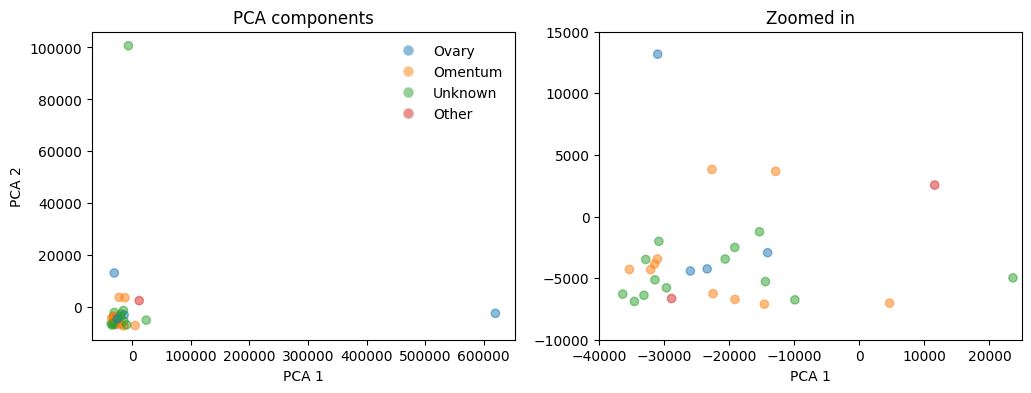

In [193]:
color = ["C0" if x=="Ovary" else "C1" if x=="Omentum" else "C2" if x=="Unknown" else "C3" for x in metadata_df]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(components[:, 0], components[:, 1], c=color, alpha=0.5)
ax[0].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2")
ax[0].legend(
    handles=[
        Line2D([0], [0], color="w", marker='o', markerfacecolor="C0", markersize=8, alpha=0.5),
        Line2D([0], [0], color="w", marker='o', markerfacecolor="C1", markersize=8, alpha=0.5),
        Line2D([0], [0], color="w", marker='o', markerfacecolor="C2", markersize=8, alpha=0.5),
        Line2D([0], [0], color="w", marker='o', markerfacecolor="C3", markersize=8, alpha=0.5)
    ],
    labels=["Ovary", "Omentum", "Unknown", "Other"],
    frameon=False,
    loc='upper right'
)
ax[0].set_title("PCA components")
# I suspect that the explained variance of PCA 1 being very highly is at least partially due to the outliers in 230414

ax[1].scatter(components[:, 0], components[:, 1], c=color, alpha=0.5)
ax[1].set_ylim([-1e4, 1.5e4])
ax[1].set_xlim([-4e4, 2.5e4])
ax[1].set_xlabel("PCA 1")
ax[1].set_title("Zoomed in")

plt.show()

In [ ]:
figname = f"{os.getcwd()}/../results/figures/PCA_plot_diss_bulk_site_of_origin"
fig.savefig(figname + ".png", bbox_inches="tight")
fig.savefig(figname + ".pdf", bbox_inches="tight")